# 🍷 Notebook 01 — Preprocesamiento de Datos

**Proyecto 1 · Curso Machine Learning Engineering (DSRP 2026)**

Dataset: [Red Wine Quality](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv) — UCI Machine Learning Repository

**Objetivo:** Predecir si un vino tinto es de *buena calidad* (puntuación ≥ 6) o *mala calidad* (< 6) a partir de sus características físico-químicas.

**Contenido de este notebook:**
1. Carga y exploración inicial de datos (EDA)
2. Análisis de la variable objetivo
3. Correlaciones y distribuciones de features
4. Preprocesamiento: escalado y split train/test
5. Persistencia de artefactos

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Importar módulo reutilizable del proyecto
sys.path.insert(0, os.path.abspath('..'))
from src.preprocessing import (
    load_data, create_binary_target, split_features_target,
    scale_features, DATA_URL, FEATURE_COLS
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente ✓')


Librerías cargadas correctamente ✓


In [2]:
# Configuración de rutas del proyecto
PROJECT_ROOT  = os.path.abspath('..')
DATA_DIR      = os.path.join(PROJECT_ROOT, 'data')
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, 'artifacts')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f'PROJECT_ROOT:  {PROJECT_ROOT}')
print(f'DATA_DIR:      {DATA_DIR}')
print(f'ARTIFACTS_DIR: {ARTIFACTS_DIR}')


PROJECT_ROOT:  /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1
DATA_DIR:      /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/data
ARTIFACTS_DIR: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts


## 1. Carga de Datos

Descargamos el dataset directamente desde el UCI Machine Learning Repository.

In [3]:
df_raw = load_data(DATA_URL)

# Persistir copia local
raw_path = os.path.join(DATA_DIR, 'winequality-red.csv')
df_raw.to_csv(raw_path, index=False, sep=';')

print(f'Dimensiones:   {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print(f'Guardado en:   {raw_path}')
print()
df_raw.head()


Dimensiones:   1599 filas × 12 columnas
Guardado en:   /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/data/winequality-red.csv



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
print('=== Tipos de datos ===')
print(df_raw.dtypes.to_string())
print()
print('=== Estadísticas descriptivas ===')
df_raw.describe().round(3)


=== Tipos de datos ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64

=== Estadísticas descriptivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [5]:
# Verificación de valores nulos y duplicados
nulls = df_raw.isnull().sum()
dupes = df_raw.duplicated().sum()

print('=== Calidad de datos ===')
if nulls.sum() == 0:
    print('  Valores nulos:    0  ✓')
else:
    print(f'  Valores nulos:\n{nulls[nulls > 0]}')

print(f'  Filas duplicadas: {dupes}')
if dupes > 0:
    print('  → Se eliminarán duplicados en el preprocesamiento')


=== Calidad de datos ===
  Valores nulos:    0  ✓
  Filas duplicadas: 240
  → Se eliminarán duplicados en el preprocesamiento


## 2. Análisis de la Variable Objetivo

El dataset tiene calidades del 3 al 8. Binarizamos con umbral **≥ 6 = buena calidad**.

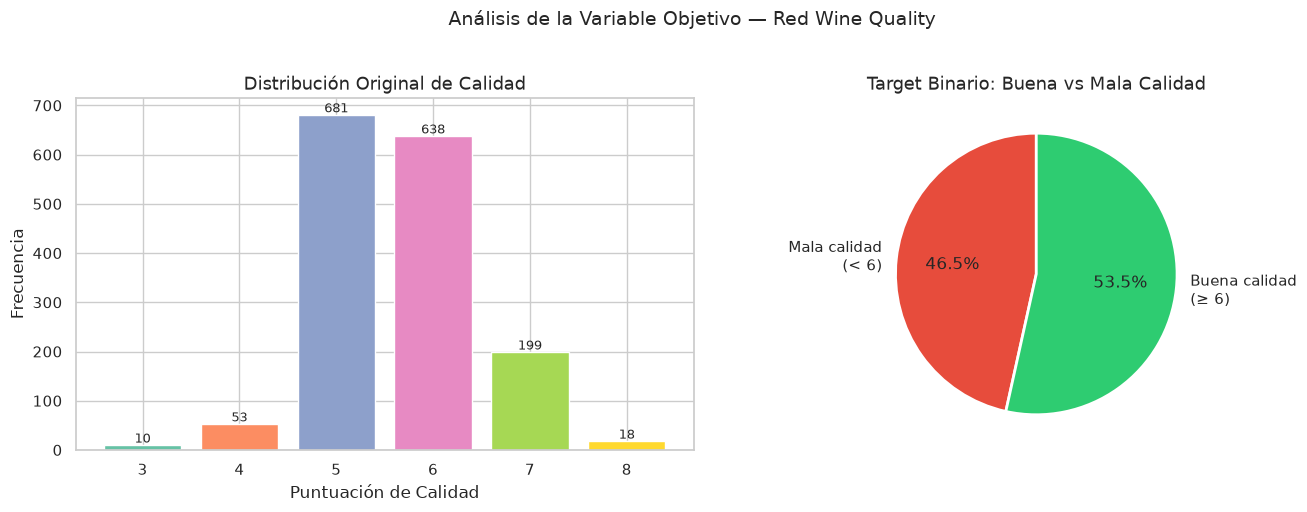

Clase 0 (mala calidad):   744 (46.5%)
Clase 1 (buena calidad):  855 (53.5%)
Balance del dataset:     53.5% positivos


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribución original de puntuaciones ──
quality_counts = df_raw['quality'].value_counts().sort_index()
colors = sns.color_palette('Set2', len(quality_counts))
bars = axes[0].bar(quality_counts.index, quality_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Puntuación de Calidad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución Original de Calidad', fontsize=13)
for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=9)

# ── Target binario ──
df = create_binary_target(df_raw, 'quality', threshold=6)
binary_counts = df['quality_binary'].value_counts().sort_index()
pie_labels = ['Mala calidad\n(< 6)', 'Buena calidad\n(≥ 6)']
axes[1].pie(binary_counts.values,
            labels=pie_labels,
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Binario: Buena vs Mala Calidad', fontsize=13)

plt.suptitle('Análisis de la Variable Objetivo — Red Wine Quality', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'target_distribution.png'), bbox_inches='tight', dpi=120)
plt.show()

print(f'Clase 0 (mala calidad):  {binary_counts[0]:>4} ({binary_counts[0]/len(df):.1%})')
print(f'Clase 1 (buena calidad): {binary_counts[1]:>4} ({binary_counts[1]/len(df):.1%})')
print(f'Balance del dataset:     {df["quality_binary"].mean():.1%} positivos')


## 3. Análisis Exploratorio (EDA)

### 3.1 Mapa de Correlación

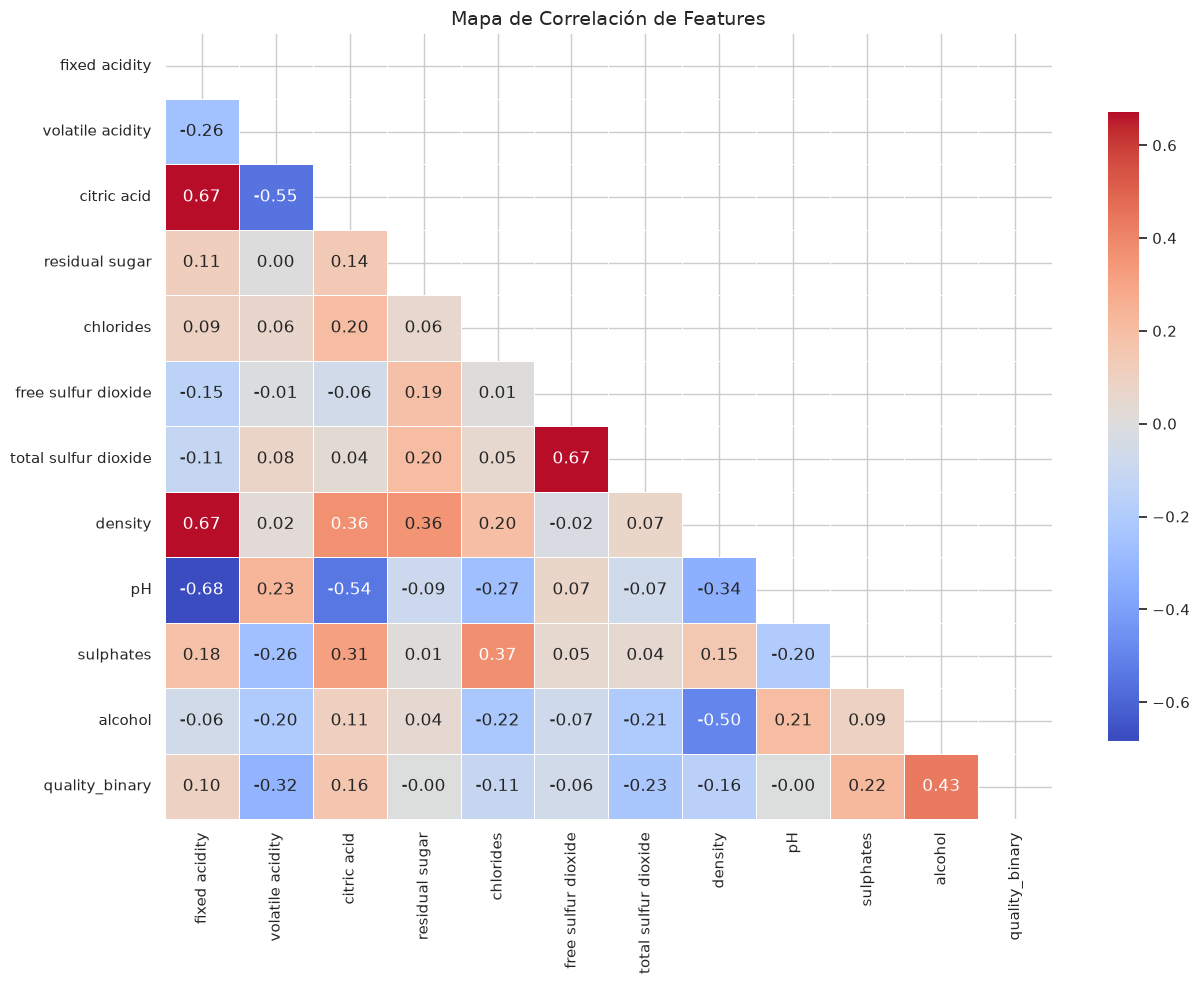

=== Top correlaciones con quality_binary ===
  alcohol                   0.4348  ████████
  volatile acidity          0.3214  ██████
  total sulfur dioxide      0.2320  ████
  sulphates                 0.2181  ████
  citric acid               0.1591  ███
  density                   0.1591  ███
  chlorides                 0.1095  ██
  fixed acidity             0.0951  █
  free sulfur dioxide       0.0618  █
  pH                        0.0033  
  residual sugar            0.0022  


In [7]:
fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = df[FEATURE_COLS + ['quality_binary']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=False,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Mapa de Correlación de Features', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'correlation_heatmap.png'), bbox_inches='tight', dpi=120)
plt.show()

print('=== Top correlaciones con quality_binary ===')
target_corr = corr_matrix['quality_binary'].drop('quality_binary').abs().sort_values(ascending=False)
for feat, corr_val in target_corr.items():
    bar = '█' * int(corr_val * 20)
    print(f'  {feat:<25} {corr_val:.4f}  {bar}')


### 3.2 Distribuciones por Clase

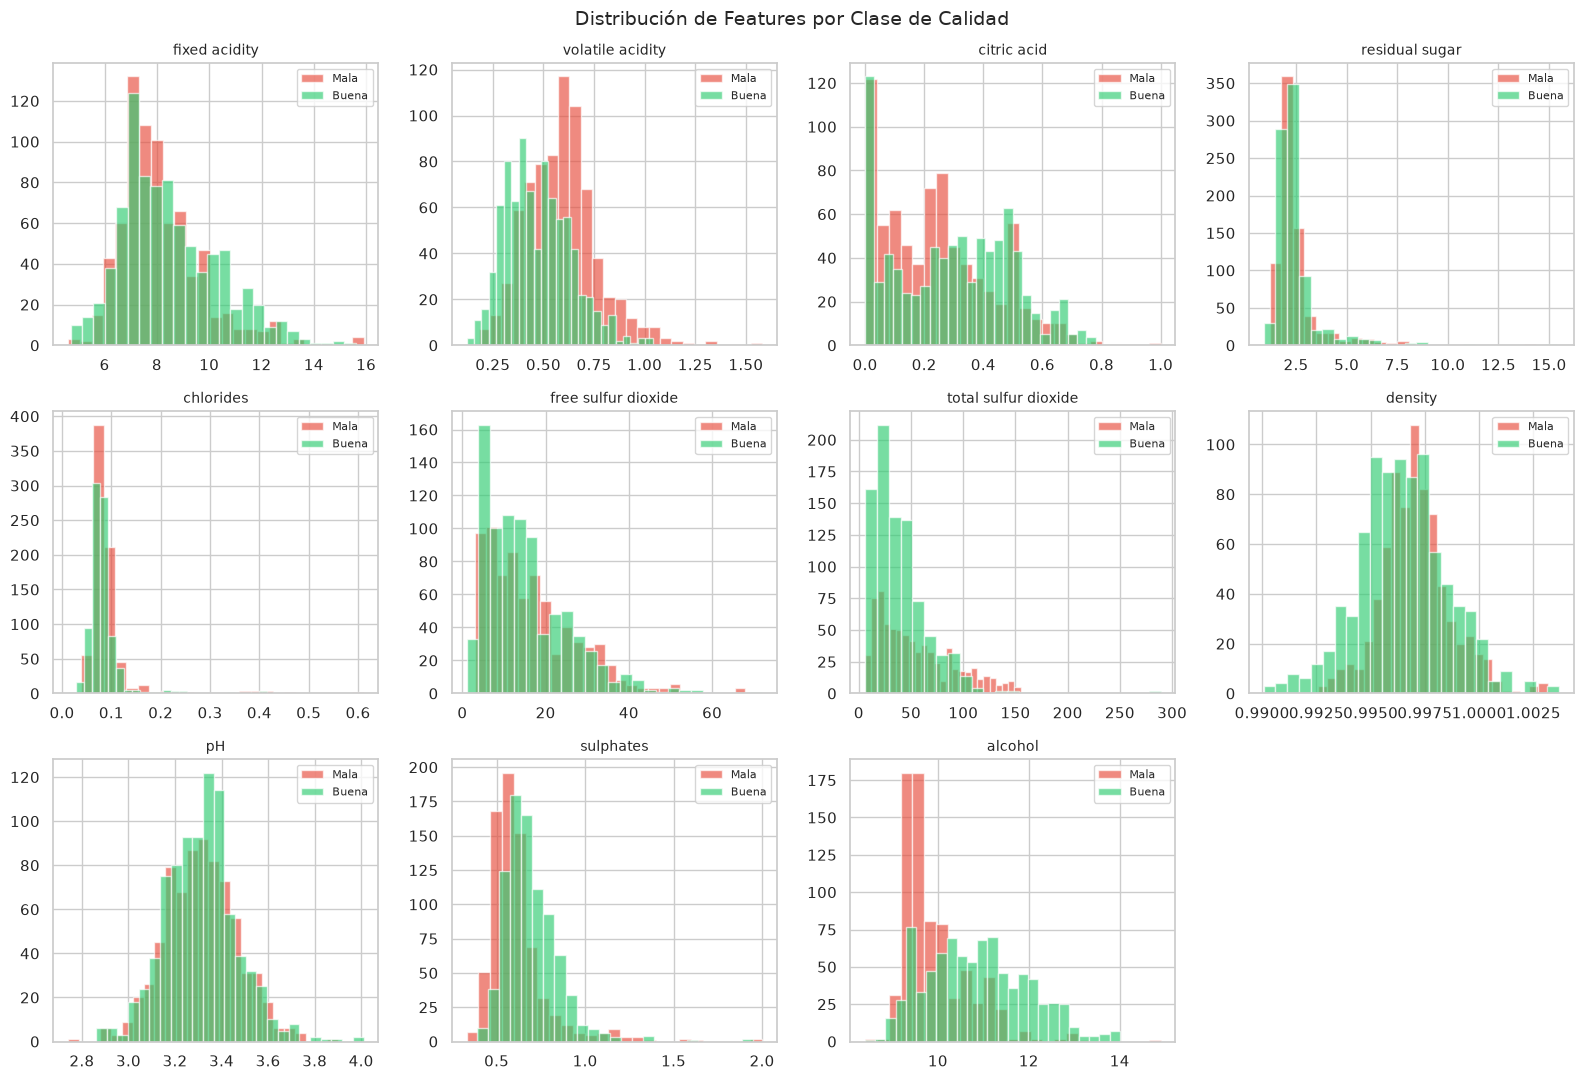

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    for cls, label, color in [(0, 'Mala', '#e74c3c'), (1, 'Buena', '#2ecc71')]:
        axes[i].hist(df[df['quality_binary'] == cls][col],
                     bins=25, alpha=0.65, label=label, color=color, edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribución de Features por Clase de Calidad', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'feature_distributions.png'), bbox_inches='tight', dpi=120)
plt.show()


### 3.3 Boxplots — Top Features más Correlacionadas

Top 6 features más correlacionadas con el target:
  • alcohol
  • volatile acidity
  • total sulfur dioxide
  • sulphates
  • citric acid
  • density


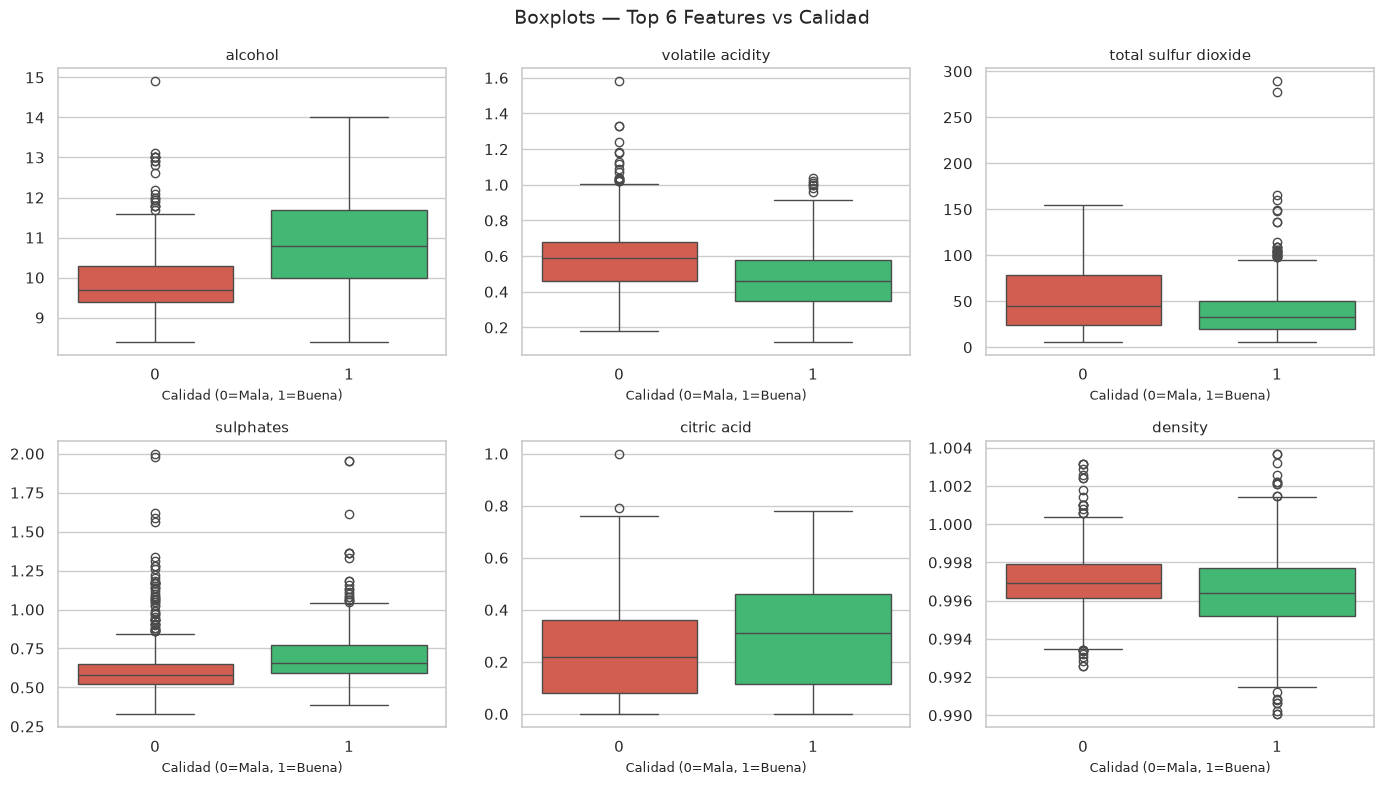

In [9]:
top_features = target_corr.head(6).index.tolist()
print('Top 6 features más correlacionadas con el target:')
for f in top_features:
    print(f'  • {f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = {'0': '#e74c3c', '1': '#2ecc71'}

for i, col in enumerate(top_features):
    sns.boxplot(data=df, x='quality_binary', y=col, ax=axes[i],
                palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Calidad (0=Mala, 1=Buena)', fontsize=9)
    axes[i].set_ylabel('')

plt.suptitle('Boxplots — Top 6 Features vs Calidad', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'feature_boxplots.png'), bbox_inches='tight', dpi=120)
plt.show()


## 4. Preprocesamiento

**Pasos:**
1. Eliminar filas duplicadas
2. División estratificada Train (80%) / Test (20%)
3. Escalado con `StandardScaler` ajustado **solo en train** (evitar data leakage)
4. Persistencia en formato Parquet

In [10]:
# Eliminar duplicados
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Filas tras eliminar duplicados: {len(df_clean)} (se eliminaron {len(df) - len(df_clean)})')

# Separar features y target
X, y = split_features_target(df_clean, 'quality_binary', FEATURE_COLS)

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar features
scaler_path = os.path.join(ARTIFACTS_DIR, 'scaler.pkl')
X_train_sc, X_test_sc, scaler = scale_features(X_train, X_test, save_path=scaler_path)

print(f'\nTrain: {X_train_sc.shape[0]} muestras — {y_train.mean():.1%} positivos')
print(f'Test:  {X_test_sc.shape[0]} muestras  — {y_test.mean():.1%} positivos')
print(f'Features: {X_train_sc.shape[1]}')
print(f'\nEscalador guardado en: {scaler_path}  ✓')


Filas tras eliminar duplicados: 1359 (se eliminaron 240)

Train: 1087 muestras — 52.9% positivos
Test:  272 muestras  — 52.9% positivos
Features: 11

Escalador guardado en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/scaler.pkl  ✓


In [11]:
# Persistir conjuntos preprocesados como Parquet
train_df = pd.DataFrame(X_train_sc, columns=FEATURE_COLS)
train_df['quality_binary'] = y_train.values
train_path = os.path.join(DATA_DIR, 'preprocessed_train.parquet')
train_df.to_parquet(train_path, index=False)

test_df = pd.DataFrame(X_test_sc, columns=FEATURE_COLS)
test_df['quality_binary'] = y_test.values
test_path = os.path.join(DATA_DIR, 'preprocessed_test.parquet')
test_df.to_parquet(test_path, index=False)

print(f'✓ Train guardado:  {train_path}  {train_df.shape}')
print(f'✓ Test  guardado:  {test_path}   {test_df.shape}')

# Verificación rápida
print()
print('Muestra del conjunto de entrenamiento preprocesado:')
train_df.head(3)


✓ Train guardado:  /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/data/preprocessed_train.parquet  (1087, 12)
✓ Test  guardado:  /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/data/preprocessed_test.parquet   (272, 12)

Muestra del conjunto de entrenamiento preprocesado:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_binary
0,-0.805013,-0.44005,-0.827412,-0.104942,-0.891400,-0.947963,-1.022542,-1.695844,-0.076917,-0.051065,0.882794,1
1,-0.805013,-0.49436,-1.385634,-0.823728,-0.360597,1.560940,-0.257196,-1.247373,0.053518,-0.454964,0.882794,1
2,-0.060680,-0.54867,0.086042,-0.679971,-0.144344,1.078459,-0.051141,-0.366447,-0.403005,-0.685764,-0.131011,0


In [12]:
print('=' * 55)
print(' RESUMEN DEL PREPROCESAMIENTO')
print('=' * 55)
print(f'  Dataset original:     {df_raw.shape[0]:>5} filas × {df_raw.shape[1]} columnas')
print(f'  Duplicados removidos: {len(df_raw) - len(df_clean):>5}')
print(f'  Dataset limpio:       {len(df_clean):>5} filas')
print(f'  Valores nulos:        {df_clean.isnull().sum().sum():>5}')
print(f'  Balance del target:   {df_clean["quality_binary"].mean():.1%} positivos')
print(f'  Train / Test:         {len(X_train):>4} / {len(X_test)} muestras')
print(f'  Escalado:             StandardScaler (fit solo en train)')
print()
print('  Artefactos generados:')
artifacts = [
    'data/winequality-red.csv',
    'data/preprocessed_train.parquet',
    'data/preprocessed_test.parquet',
    'artifacts/scaler.pkl',
    'artifacts/target_distribution.png',
    'artifacts/correlation_heatmap.png',
    'artifacts/feature_distributions.png',
    'artifacts/feature_boxplots.png',
]
for a in artifacts:
    print(f'    • {a}')
print('=' * 55)


 RESUMEN DEL PREPROCESAMIENTO
  Dataset original:      1599 filas × 12 columnas
  Duplicados removidos:   240
  Dataset limpio:        1359 filas
  Valores nulos:            0
  Balance del target:   52.9% positivos
  Train / Test:         1087 / 272 muestras
  Escalado:             StandardScaler (fit solo en train)

  Artefactos generados:
    • data/winequality-red.csv
    • data/preprocessed_train.parquet
    • data/preprocessed_test.parquet
    • artifacts/scaler.pkl
    • artifacts/target_distribution.png
    • artifacts/correlation_heatmap.png
    • artifacts/feature_distributions.png
    • artifacts/feature_boxplots.png


In [13]:

# Generar data/dataset_summary.txt — cubre el requisito de .txt en la carpeta data/
summary_lines = [
    '=' * 55,
    ' RESUMEN DEL DATASET — Red Wine Quality (UCI)',
    '=' * 55,
    f'Fuente:          {DATA_URL}',
    f'Filas brutas:    {len(df_raw)}',
    f'Filas únicas:    {len(df_clean)}',
    f'Duplicados:      {len(df_raw) - len(df_clean)}',
    f'Features:        {len(FEATURE_COLS)}',
    f'Valores nulos:   {df_raw.isnull().sum().sum()}',
    '',
    'DISTRIBUCIÓN DEL TARGET (quality_binary):',
    f"  Clase 0 (mala calidad  < 6):  {(df_clean['quality_binary'] == 0).sum()} muestras",
    f"  Clase 1 (buena calidad >= 6): {(df_clean['quality_binary'] == 1).sum()} muestras",
    '',
    'SPLIT TRAIN / TEST:',
    f'  Train: {len(X_train_sc)} muestras (80%)',
    f'  Test:  {len(X_test_sc)} muestras  (20%, estratificado)',
    '',
    'TOP 5 CORRELACIONES CON EL TARGET:',
]
for feat, corr_val in target_corr.head(5).items():
    summary_lines.append(f'  {feat:<28} r = {corr_val:.4f}')

summary_lines += [
    '',
    'ESTADÍSTICAS CLAVE (valores originales, sin escalar):',
]
for col in ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']:
    s = df_raw[col]
    summary_lines.append(
        f'  {col:<28} mean={s.mean():.3f}  std={s.std():.3f}  '
        f'min={s.min():.3f}  max={s.max():.3f}'
    )
summary_lines.append('=' * 55)

summary_text = '\n'.join(summary_lines)
summary_path = os.path.join(DATA_DIR, 'dataset_summary.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(summary_text)
print(f'\n✓ Resumen guardado en: {summary_path}')


 RESUMEN DEL DATASET — Red Wine Quality (UCI)
Fuente:          https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
Filas brutas:    1599
Filas únicas:    1359
Duplicados:      240
Features:        11
Valores nulos:   0

DISTRIBUCIÓN DEL TARGET (quality_binary):
  Clase 0 (mala calidad  < 6):  640 muestras
  Clase 1 (buena calidad >= 6): 719 muestras

SPLIT TRAIN / TEST:
  Train: 1087 muestras (80%)
  Test:  272 muestras  (20%, estratificado)

TOP 5 CORRELACIONES CON EL TARGET:
  alcohol                      r = 0.4348
  volatile acidity             r = 0.3214
  total sulfur dioxide         r = 0.2320
  sulphates                    r = 0.2181
  citric acid                  r = 0.1591

ESTADÍSTICAS CLAVE (valores originales, sin escalar):
  alcohol                      mean=10.423  std=1.066  min=8.400  max=14.900
  volatile acidity             mean=0.528  std=0.179  min=0.120  max=1.580
  sulphates                    mean=0.658  std=0.170  min=0.33

## 5. Conclusiones del Preprocesamiento

- El dataset es **limpio**: no hay valores nulos y los tipos de datos son correctos.
- Hay **1,359 filas únicas** (tras eliminar duplicados) con **11 features numéricas continuas**.
- El target binario está razonablemente **balanceado (~53% buena calidad)**.
- Las features más correlacionadas con la calidad son **alcohol**, **sulphates** y **volatile acidity**.
- Se detectó **multicolinearidad** entre `free sulfur dioxide` y `total sulfur dioxide` (r≈0.67).
- El `StandardScaler` se ajustó **solo en el conjunto de entrenamiento** para evitar data leakage.

**Siguiente paso:** `02_machine_learning_y_llms.ipynb` — Entrenamiento y evaluación de modelos.